In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, root_mean_squared_error

# Set random seed for reproducibility
np.random.seed(42)

# Generate synthetic data:
# Let's assume 'YearsExperience' ranges from 0 to 20
n_samples = 100
X = np.linspace(0, 20, n_samples).reshape(-1, 1)

# Define a quadratic relationship for Salary:
# Salary = base + coef1 * YearsExperience + coef2 * (YearsExperience)^2 + noise
base_salary = 20000
coef1 = 1000
coef2 = 200

# Generate noise
noise = np.random.normal(0, 1000, size=n_samples)

# Compute Salary using the polynomial relationship
salary = base_salary + coef1 * X.flatten() + coef2 * X.flatten()**2 + noise

# Create a DataFrame to hold our synthetic data
df = pd.DataFrame({
    'YearsExperience': X.flatten(),
    'Salary': salary
})

print("Synthetic Salary Data:")
df

Synthetic Salary Data:


,YearsExperience,Salary
0,0.000000,20496.714153
1,0.202020,20071.918333
2,0.404040,21084.378672
3,0.606061,22202.552354
4,0.808081,20704.526352
...,...,...
95,19.191919,111394.356698
96,19.393939,114915.036714
97,19.595960,116657.341365
98,19.797980,118195.094071


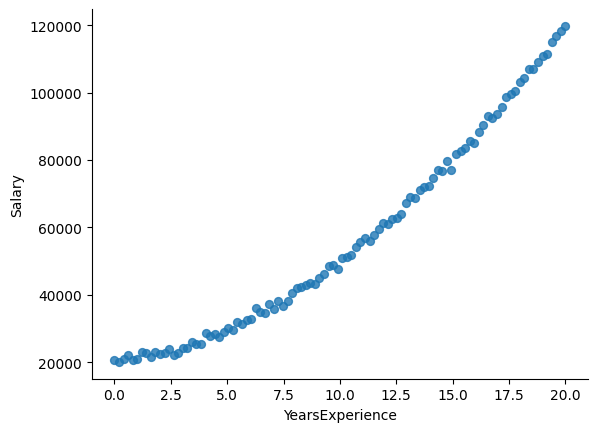

In [ ]:
from matplotlib import pyplot as plt
df.plot(kind='scatter', x='YearsExperience', y='Salary', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)


Mean Squared Error: 878.84


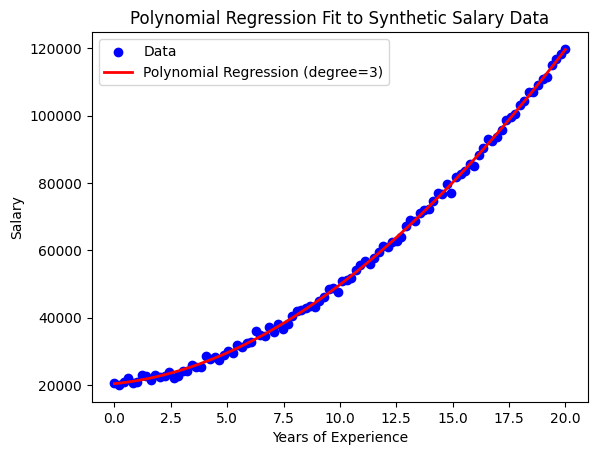

In [ ]:

# ----- Polynomial Regression -----
# Choose the degree of the polynomial (quadratic in this case)
degree = 3

# Transform features to polynomial features
poly_features = PolynomialFeatures(degree=degree)
X_poly = poly_features.fit_transform(X)

# Fit the polynomial regression model
model = LinearRegression()
model.fit(X_poly, salary)
salary_pred = model.predict(X_poly)

# Calculate model performance
mse = root_mean_squared_error(salary, salary_pred)
print(f"\nMean Squared Error: {mse:.2f}")

# ----- Plotting the Results -----
plt.scatter(X, salary, color='blue', label='Data')
plt.plot(X, salary_pred, color='red', linewidth=2, label=f'Polynomial Regression (degree={degree})')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.title('Polynomial Regression Fit to Synthetic Salary Data')
plt.legend()
plt.show()

# Your assignement

,YearsExperience,Age,Bonus,Education,Department,Salary
0,0.00000,60.0,3309.070982,Bachelor,IT,25242.338467
1,0.02002,50.0,1026.041183,Master,IT,30490.693060
2,0.04004,36.0,4729.244556,Bachelor,IT,28212.376087
3,0.06006,64.0,3324.686239,Bachelor,IT,29247.480603
4,0.08008,NaN,2007.075266,NaN,Sales,26323.877776
...,...,...,...,...,...,...
995,19.91992,54.0,2372.692992,Master,IT,150162.190180
996,19.93994,NaN,2666.048682,Master,Sales,160993.535447
997,19.95996,35.0,586.365246,Master,IT,150820.910193
998,NaN,61.0,1669.159439,Bachelor,IT,132690.622371


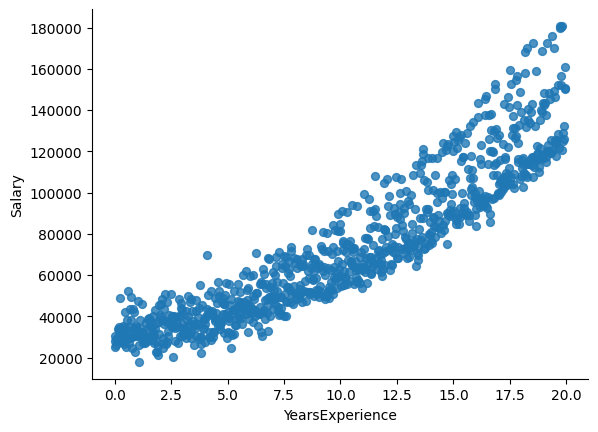

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler, OneHotEncoder
from sklearn.metrics import mean_squared_error
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split

# Set random seed for reproducibility
np.random.seed(42)

# Number of samples
n_samples = 1000

# Generate primary numerical features
# YearsExperience: uniformly distributed between 0 and 20
years_experience = np.linspace(0, 20, n_samples)

# Age: uniformly distributed between 22 and 65
age = np.random.randint(22, 66, size=n_samples)

# Bonus: randomly generated between 500 and 5000
bonus = np.random.uniform(500, 5000, size=n_samples)

# Categorical features
# Education: 'Bachelor', 'Master', 'PhD'
education_levels = np.random.choice(['Bachelor', 'Master', 'PhD'], size=n_samples, p=[0.5, 0.3, 0.2])
# Department: 'Sales', 'HR', 'IT'
departments = np.random.choice(['Sales', 'HR', 'IT'], size=n_samples)
dept_multiplier = {'Sales': 1.0, 'HR': 0.9, 'IT': 1.1}

# Define multipliers for Education to simulate its impact on Salary
education_multiplier = {'Bachelor': 1.0, 'Master': 1.1, 'PhD': 1.2}

# Construct the target Salary as a function of:
# - A quadratic relationship with YearsExperience
# - A linear term in Age
# - A contribution from Bonus
# - An education factor applied multiplicatively
# - Added noise for realism
base_salary = 20000
coef_exp_linear = 1000
coef_exp_quad = 200
coef_age = 100

# Generate noise
noise = np.random.normal(0, 2000, n_samples)

# Calculate raw salary
salary = (
    base_salary +
    coef_exp_linear * years_experience +
    coef_exp_quad * (years_experience ** 2) +
    coef_age * age +
    bonus
)

# Apply the education multiplier (convert categorical string array to multipliers)
edu_multiplier = np.array([education_multiplier[edu] for edu in education_levels])
salary = salary * edu_multiplier + noise

# Apply the department multiplier (convert categorical string array to multipliers)
dept_multiplier = np.array([education_multiplier[edu] for edu in education_levels])
salary = salary * edu_multiplier + noise


# Create a DataFrame
data = pd.DataFrame({
    'YearsExperience': years_experience,
    'Age': age,
    'Bonus': bonus,
    'Education': education_levels,
    'Department': departments,
    'Salary': salary
})

# ----- Introduce Random NaN Values -----
# Define fraction of missing values to introduce in each column (except Salary)
nan_fraction = 0.1  # 10% missing values

for col in ['YearsExperience', 'Age', 'Bonus']:
    n_missing = int(n_samples * nan_fraction)
    missing_indices = np.random.choice(n_samples, size=n_missing, replace=False)
    data.loc[missing_indices, col] = np.nan

# For categorical features, randomly set some entries to NaN as well
for col in ['Education', 'Department']:
    n_missing = int(n_samples * nan_fraction)
    missing_indices = np.random.choice(n_samples, size=n_missing, replace=False)
    data.loc[missing_indices, col] = np.nan


from matplotlib import pyplot as plt
data.plot(kind='scatter', x='YearsExperience', y='Salary', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

data

In [ ]:
# Load vector X and y

X = data.iloc[:, :-1].values
y = data.iloc[:, -1].values

print(X[:5])

## Handle missing data

In [ ]:
from sklearn.impute import SimpleImputer


## Encoding categories

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import make_column_transformer

In [ ]:
# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Scale features
from sklearn.preprocessing import StandardScaler

# Train Regression Model

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, root_mean_squared_error

# Evaluate Model Performence

In [ ]:
y_pred = ...